# 03 — Segmentação por Métodos Tradicionais

Aplica e avalia os métodos tradicionais de segmentação (Otsu, Watershed, GrabCut)
nas imagens pré-processadas pelo pipeline do `02_preprocessing.ipynb`.

Seções:
1. Segmentação visual em uma imagem de teste
2. Métricas (Jaccard / Dice) vs. ground truth
3. Validação em mais 3 imagens
4. Rodada completa no dataset — apenas métricas e gráfico final


In [1]:
import sys
sys.path.insert(0, '..')

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.transform import resize

from src.utils import load_image, show_comparison
from src.preprocessing import Pipeline
from src.evaluation import calculate_jaccard_dice, evaluate_segmentation
from src.segmentation.segmentation import Segmentation

with open('../../config.yaml') as f:
    cfg = yaml.safe_load(f)

pipeline  = Pipeline(cfg)
segment   = Segmentation(cfg)
print('Pipeline e Segmentation carregados.')


Pipeline e Segmentation carregados.


## 1. Carregar imagem de teste e sua máscara

Shape: (767, 1022, 3) | dtype: uint8
Shape: (767, 1022, 3) | dtype: uint8


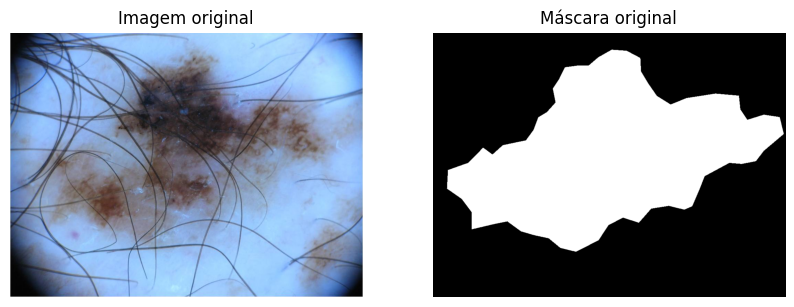

In [3]:
# Altere o caminho para qualquer imagem do ISIC 2018
IMAGE_PATH = '../data/raw/training/input/ISIC_0000074.jpg'
MASK_PATH = '../data/raw/training/groundTruth/ISIC_0000074_segmentation.png'

img_original = load_image(IMAGE_PATH)
mask_original = load_image(MASK_PATH)
print(f'Shape: {img_original.shape} | dtype: {img_original.dtype}')
print(f'Shape: {mask_original.shape} | dtype: {mask_original.dtype}')

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_original[:, :, ::-1])  # BGR -> RGB
plt.title('Imagem original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask_original, cmap='gray')
plt.title('Máscara original')
plt.axis('off')

plt.show()

## 2. Segmentação por Limiarização de Otsu, Watershed e GrabCut


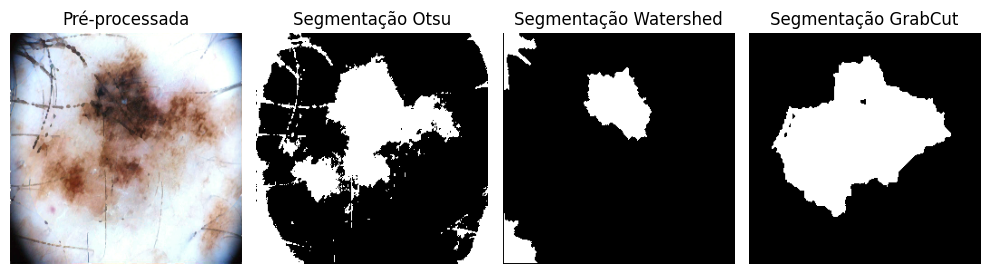

In [4]:
img_cc = pipeline.step_color_constancy(img_original)
img_hr = pipeline.step_hair_removal(img_cc)
img_clahe = pipeline.step_clahe(img_hr)
img_preprocessed = pipeline.step_resize(img_clahe)

# Segmentação tradicional usando a imagem pré-processada
mask_pred_otsu = segment.step_segment_traditional_otsu(img_preprocessed)
mask_pred_watershed = segment.step_segment_traditional_watershed(img_preprocessed)
mask_pred_grabcut = segment.step_segment_traditional_grabcut(img_preprocessed)


show_comparison({
    'Pré-processada': img_preprocessed,
    'Segmentação Otsu': mask_pred_otsu * 255,  # para visualização
    'Segmentação Watershed': mask_pred_watershed * 255,  # para visualização
    'Segmentação GrabCut': mask_pred_grabcut * 255,  # para visualização
}, figsize=(10, 5))

## 3. Métricas de Avalição para Segmentação 

Índice Jaccard e Coeficiente de Dice, ambas comparam a similaridade de dados.

In [5]:
from skimage.transform import resize

if mask_original.ndim == 3:
    mask_original = mask_original[..., 0]

mask_original_resized = resize(mask_original, mask_pred_otsu.shape, order=0, preserve_range=True, anti_aliasing=False).astype(mask_pred_otsu.dtype)

print(mask_original_resized.shape, mask_pred_otsu.shape)
print(mask_original_resized.shape, mask_pred_watershed.shape)
print(mask_original_resized.shape, mask_pred_grabcut.shape)

(256, 256) (256, 256)
(256, 256) (256, 256)
(256, 256) (256, 256)


In [6]:
# Binariza as máscaras para 0 e 1 (necessário para métricas do scikit-learn)
mask_original_bin = (mask_original_resized > 0).astype(np.uint8)
mask_pred_otsu_bin = (mask_pred_otsu > 0).astype(np.uint8)
mask_pred_watershed_bin = (mask_pred_watershed > 0).astype(np.uint8)
mask_pred_grabcut_bin = (mask_pred_grabcut > 0).astype(np.uint8)

variants_segmentation = {
    'Otsu': mask_pred_otsu_bin,
    'Watershed': mask_pred_watershed_bin,
    'GrabCut': mask_pred_grabcut_bin,
}

results_segmentation = evaluate_segmentation(mask_original_bin, variants_segmentation)
df_segmentation = pd.DataFrame(results_segmentation)
df_segmentation.to_csv('../results/metrics/segmentation_variants.csv', index=False)
print('Comparação entre as segmentações:')
display(df_segmentation)

Comparação entre as segmentações:


,name,jaccard,dice
0,Otsu,0.392866,0.564112
1,Watershed,0.138585,0.243434
2,GrabCut,0.689863,0.816472


## 4. Validação dos modelos de segmentação e das métricas a partir de mais 3 imagens

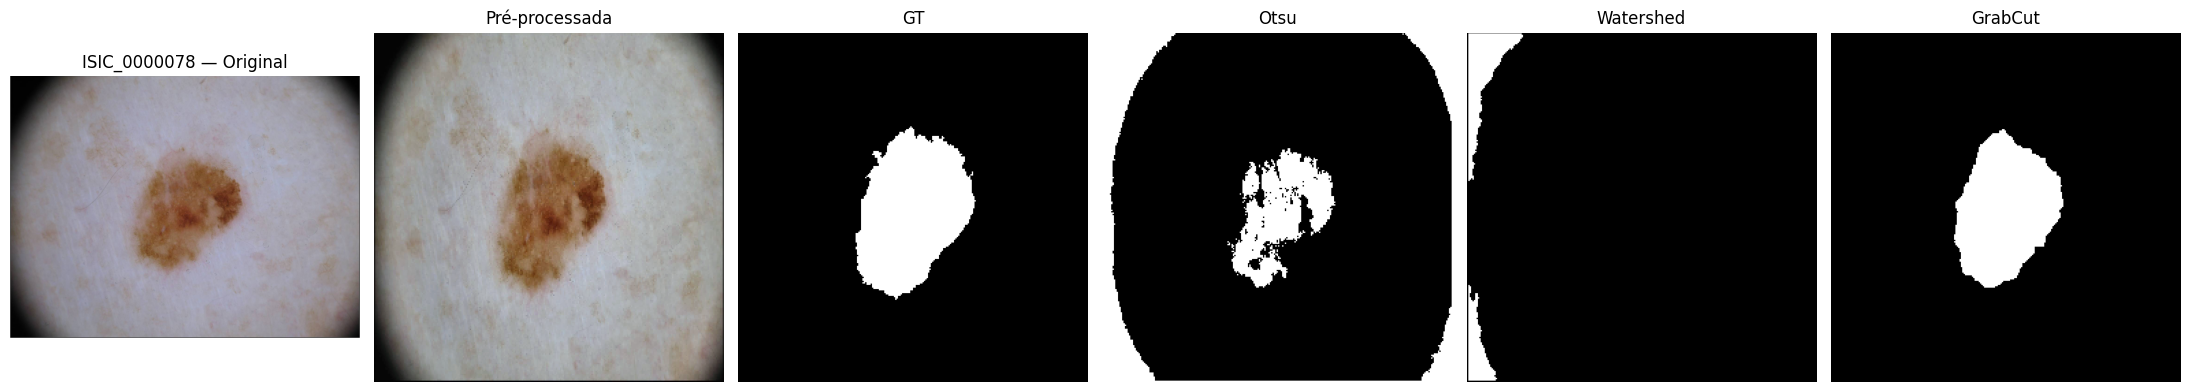

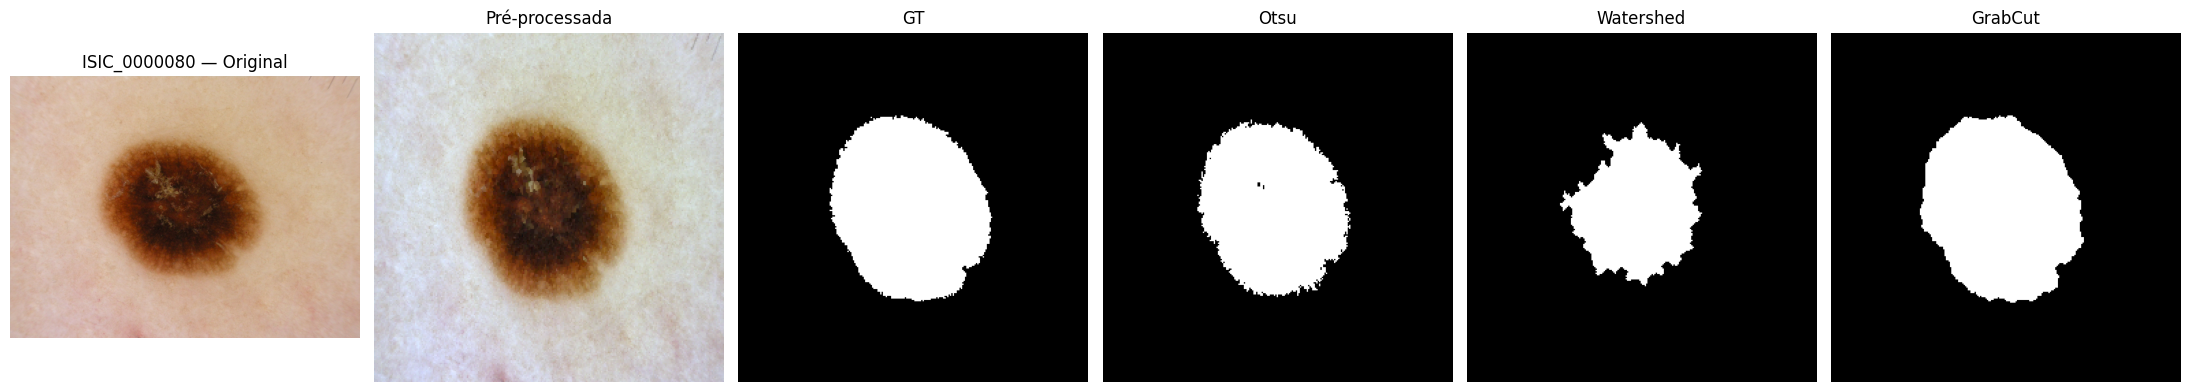

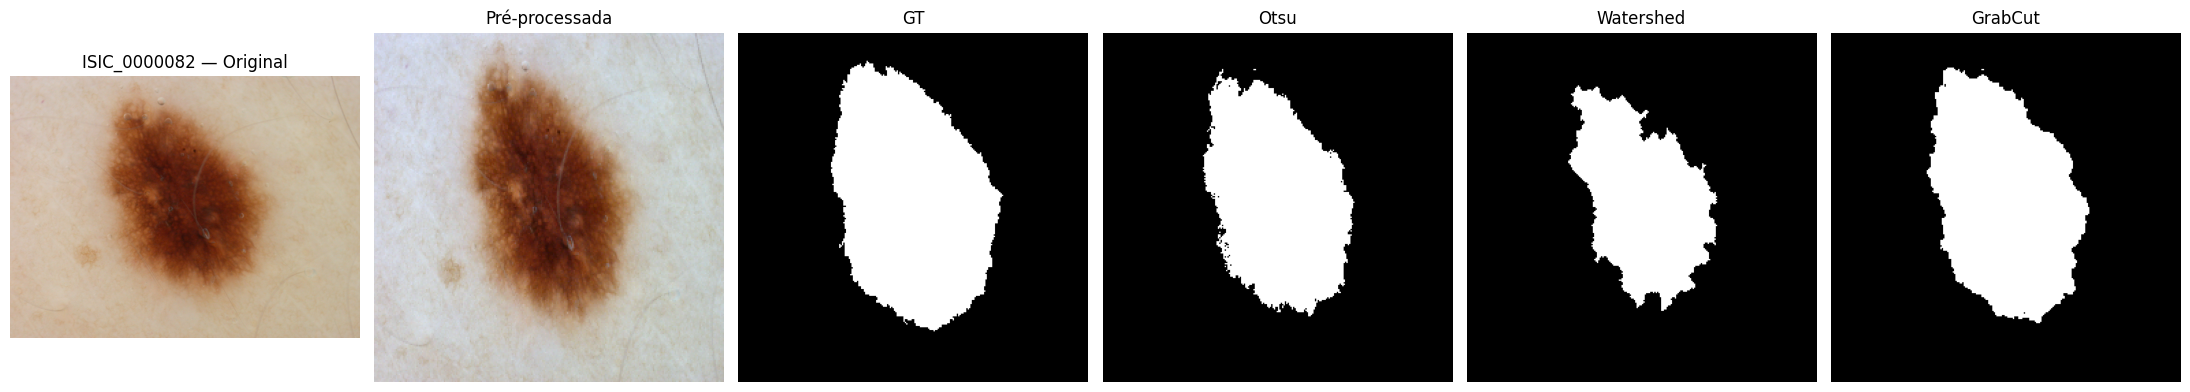

Resultados consolidados das 4 imagens:


,image,name,jaccard,dice
0,ISIC_0000074,GrabCut,0.689863,0.816472
1,ISIC_0000074,Watershed,0.138585,0.243434
2,ISIC_0000074,Otsu,0.392866,0.564112
3,ISIC_0000078,Otsu,0.281008,0.438730
4,ISIC_0000078,Watershed,0.000000,0.000000
5,ISIC_0000078,GrabCut,0.834709,0.909909
6,ISIC_0000080,Otsu,0.871653,0.931426
7,ISIC_0000080,Watershed,0.611583,0.758984
8,ISIC_0000080,GrabCut,0.964398,0.981876
9,ISIC_0000082,Otsu,0.784196,0.879047


Resumo por método (média ± desvio):


jaccard            dice        
             mean     std    mean     std
name                                     
GrabCut    0.8416  0.1147  0.9108  0.0696
Otsu       0.5824  0.2893  0.7033  0.2397
Watershed  0.3435  0.3217  0.4427  0.3837

In [7]:
# Caminhos das 3 imagens adicionais e suas máscaras de ground truth
# Altere os caminhos conforme necessário
EXTRA_IMAGES = [
    {
        "image": "../data/raw/training/input/ISIC_0000078.jpg",
        "mask":  "../data/raw/training/groundTruth/ISIC_0000078_segmentation.png",
        "name":  "ISIC_0000078",
    },
    {
        "image": "../data/raw/training/input/ISIC_0000080.jpg",
        "mask":  "../data/raw/training/groundTruth/ISIC_0000080_segmentation.png",
        "name":  "ISIC_0000080",
    },
    {
        "image": "../data/raw/training/input/ISIC_0000082.jpg",
        "mask":  "../data/raw/training/groundTruth/ISIC_0000082_segmentation.png",
        "name":  "ISIC_0000082",
    },
]

all_results = []

for entry in EXTRA_IMAGES:
    img = load_image(entry["image"])
    mask_gt = load_image(entry["mask"])

    # Mesmo pipeline da seção 7
    img_proc = pipeline.step_resize(
        pipeline.step_clahe(
            pipeline.step_hair_removal(
                pipeline.step_color_constancy(img)
            )
        )
    )

    # Segmentação com os três métodos
    mask_otsu      = segment.step_segment_traditional_otsu(img_proc)
    mask_watershed = segment.step_segment_traditional_watershed(img_proc)
    mask_grabcut   = segment.step_segment_traditional_grabcut(img_proc)

    # Alinha a máscara de ground truth com o shape da predita
    if mask_gt.ndim == 3:
        mask_gt = mask_gt[..., 0]
    mask_gt_resized = resize(
        mask_gt, mask_otsu.shape,
        order=0, preserve_range=True, anti_aliasing=False
    ).astype(mask_otsu.dtype)

    # Binariza
    gt_bin       = (mask_gt_resized   > 0).astype(np.uint8)
    otsu_bin     = (mask_otsu         > 0).astype(np.uint8)
    watershed_bin = (mask_watershed   > 0).astype(np.uint8)
    grabcut_bin  = (mask_grabcut      > 0).astype(np.uint8)

    # Métricas
    metrics = evaluate_segmentation(gt_bin, {
        "Otsu":      otsu_bin,
        "Watershed": watershed_bin,
        "GrabCut":   grabcut_bin,
    })
    for row in metrics:
        row["image"] = entry["name"]
    all_results.extend(metrics)

    # Visualização rápida para cada imagem extra
    show_comparison({
        f"{entry['name']} — Original":   img,
        "Pré-processada":               img_proc,
        "GT":                            mask_gt_resized,
        "Otsu":                          mask_otsu,
        "Watershed":                     mask_watershed,
        "GrabCut":                       mask_grabcut,
    }, figsize=(22, 4))

# Junta com os resultados da imagem principal (seção 8)
for row in results_segmentation:
    all_results.insert(0, {**row, "image": "ISIC_0000074"})

# Consolida e salva
df_validation = pd.DataFrame(all_results)[[ "image", "name", "jaccard", "dice" ]]
df_validation.to_csv("../results/metrics/segmentation_validation.csv", index=False)

print("Resultados consolidados das 4 imagens:")
display(df_validation)

# Resumo por método (média e desvio padrão entre imagens)
print("Resumo por método (média ± desvio):")
summary = (
    df_validation
    .groupby("name")[["jaccard", "dice"]]
    .agg(["mean", "std"])
    .round(4)
)
display(summary)

## 5. Rodar para o dataset inteiro

Sem exibição das imagens, apenas o resultado das métricas juntamente de um gráfico

2594 imagens encontradas.
  50/2594 concluídas
  100/2594 concluídas
  150/2594 concluídas
  200/2594 concluídas
  250/2594 concluídas
  300/2594 concluídas
  350/2594 concluídas
  400/2594 concluídas
  450/2594 concluídas
  500/2594 concluídas
  550/2594 concluídas
  600/2594 concluídas
  650/2594 concluídas
  700/2594 concluídas
  750/2594 concluídas
  800/2594 concluídas
  850/2594 concluídas
  900/2594 concluídas
  950/2594 concluídas
  1000/2594 concluídas
  1050/2594 concluídas
  1100/2594 concluídas
  1150/2594 concluídas
  1200/2594 concluídas
  1250/2594 concluídas
  1300/2594 concluídas
  1350/2594 concluídas
  1400/2594 concluídas
  1450/2594 concluídas
  1500/2594 concluídas
  1550/2594 concluídas
  1600/2594 concluídas
  1650/2594 concluídas
  1700/2594 concluídas
  1750/2594 concluídas
  1800/2594 concluídas
  1850/2594 concluídas
  1900/2594 concluídas
  1950/2594 concluídas
  2000/2594 concluídas
  2050/2594 concluídas
  2100/2594 concluídas
  2150/2594 concluídas
  220

jaccard            dice        
             mean     std    mean     std
name                                     
GrabCut    0.5748  0.2933  0.6760  0.2948
Otsu       0.4396  0.2659  0.5603  0.2770
Watershed  0.3069  0.2607  0.4095  0.3059

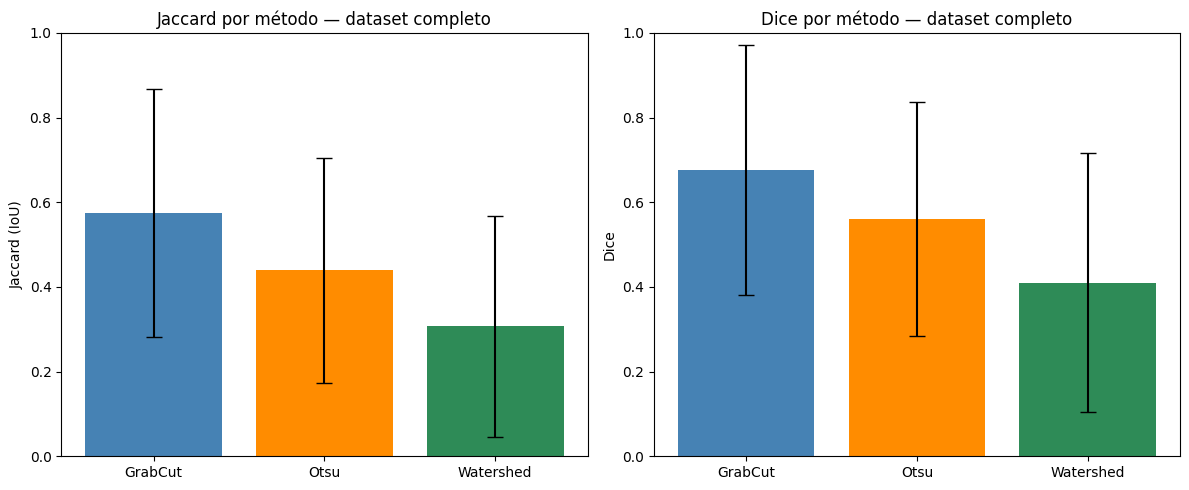

In [8]:
from pathlib import Path

INPUT_DIR  = Path('../data/raw/training/input')
GT_DIR     = Path('../data/raw/training/groundTruth')
EXTENSIONS = ('.jpg', '.jpeg', '.png')

image_paths = sorted(p for p in INPUT_DIR.iterdir() if p.suffix.lower() in EXTENSIONS)
print(f'{len(image_paths)} imagens encontradas.')

all_rows = []

for i, img_path in enumerate(image_paths, 1):
    img = load_image(str(img_path))

    # Nome base para encontrar a máscara correspondente
    stem = img_path.stem  # ex: ISIC_0000074
    mask_path = GT_DIR / f'{stem}_segmentation.png'
    if not mask_path.exists():
        print(f'  [!] Máscara não encontrada: {mask_path.name} — pulando')
        continue

    mask_gt = load_image(str(mask_path))

    # Pipeline de pré-processamento
    img_proc = pipeline.step_resize(
        pipeline.step_clahe(
            pipeline.step_hair_removal(
                pipeline.step_color_constancy(img)
            )
        )
    )

    # Segmentação
    mask_otsu      = segment.step_segment_traditional_otsu(img_proc)
    mask_watershed = segment.step_segment_traditional_watershed(img_proc)
    mask_grabcut   = segment.step_segment_traditional_grabcut(img_proc)

    # Alinha e binariza ground truth
    if mask_gt.ndim == 3:
        mask_gt = mask_gt[..., 0]
    gt = resize(mask_gt, mask_otsu.shape, order=0,
                preserve_range=True, anti_aliasing=False).astype(np.uint8)
    gt_bin = (gt > 0).astype(np.uint8)

    metrics = evaluate_segmentation(gt_bin, {
        'Otsu':      (mask_otsu      > 0).astype(np.uint8),
        'Watershed': (mask_watershed > 0).astype(np.uint8),
        'GrabCut':   (mask_grabcut   > 0).astype(np.uint8),
    })
    for row in metrics:
        row['image'] = stem
    all_rows.extend(metrics)

    if i % 50 == 0 or i == len(image_paths):
        print(f'  {i}/{len(image_paths)} concluídas')

# ── Resultados ───────────────────────────────────────────────────────────────
df_full = pd.DataFrame(all_rows)[['image', 'name', 'jaccard', 'dice']]
df_full.to_csv('../results/metrics/segmentation_full_dataset.csv', index=False)
print(f'\nCSV salvo: results/metrics/segmentation_full_dataset.csv')
print(f'Total de entradas: {len(df_full)}')

# Resumo por método
summary = (
    df_full.groupby('name')[['jaccard', 'dice']]
    .agg(['mean', 'std'])
    .round(4)
)
summary.to_csv('../results/metrics/segmentation_summary.csv')
print('\nResumo por método (média ± desvio):')
display(summary)

# Gráfico comparativo
methods = summary.index.tolist()
x = range(len(methods))
jac_mean = summary[('jaccard', 'mean')]
jac_std  = summary[('jaccard', 'std')]
dic_mean = summary[('dice',    'mean')]
dic_std  = summary[('dice',    'std')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(x, jac_mean, yerr=jac_std, capsize=6, color=['steelblue', 'darkorange', 'seagreen'])
ax1.set_xticks(x); ax1.set_xticklabels(methods)
ax1.set_ylim(0, 1); ax1.set_ylabel('Jaccard (IoU)')
ax1.set_title('Jaccard por método — dataset completo')

ax2.bar(x, dic_mean, yerr=dic_std, capsize=6, color=['steelblue', 'darkorange', 'seagreen'])
ax2.set_xticks(x); ax2.set_xticklabels(methods)
ax2.set_ylim(0, 1); ax2.set_ylabel('Dice')
ax2.set_title('Dice por método — dataset completo')

plt.tight_layout()
plt.savefig('../results/figures/segmentation_full_dataset.png', dpi=150)
plt.show()
